In [47]:
from IPython.display import Markdown
import codes

mypimes = "| Tienda | Municipio | Latitud | Longitud | Evidence |\n"
mypimes += "|--------|----------|-----------|-----------|-----------|\n"

for item in codes.js_mypimes:
    mypimes += f"| {item['name']} | {item['municipio']} | {item['latitude']} | {item['length']} | {item['evidence']} |\n"

Markdown(f"### Tiendas Físicas\n {mypimes}")

### Tiendas Físicas
 | Tienda | Municipio | Latitud | Longitud | Evidence |
|--------|----------|-----------|-----------|-----------|
| Prado_Montero | Plaza de la Revolucion  | 23.13646 | -82.383378 | pictures/PradoMontero |
| Titi Cafe | Plaza de la Revolucion  | 23.136904 | -82.383915 | pictures/TitiCafe |
| La Fortuna | Plaza de la Revolucion  | 23.136866 | -82.383908 | pictures/LaFortuna |
| El Duende | Plaza de la Revolucion  | 23.136828 | -82.383918 | pictures/ElDuende |
| Intermedio | Plaza de la Revolucion  | 23.138743 | -82.384339 | pictures/Intermedio |
| Sofia | Plaza de la Revolucion  | 23.135337 | -82.382153 | pictures/Sofia |
| Wakamba | Plaza de la Revolucion  | 23.135311 | -82.382168 | pictures/Wakamba |
| Vita Nova | Plaza de la Revolucion  | 23.136424 | -82.381496 | pictures/VitaNova |
| La Loreta | Plaza de la Revolucion  | 23.136408 | -82.381549 | pictures/LaLoreta |
| 21 y K | Plaza de la Revolucion  | 23.139753 | -82.385371 | pictures/21yK |
| El Escaparate | Plaza de la Revolucion  | 23.139632 | -82.384766 | pictures/ElEscaparate |
| La Tres Torres | Plaza de la Revolucion  | 23.138023 | -82.385637 | pictures/TresTorres |
| Luna de Cristal | Plaza de la Revolucion  | 23.136935 | -82.385432 | pictures/LunadeCristal |
| Mercadito Rubi | Plaza de la Revolucion  | 23.130304 | -82.387347 | pictures/MercaditoRubi |
| Chinshal | Plaza de la Revolucion  | 23.136165 | -82.387189 | pictures/Chinshal |
| Rey Gaby | Plaza de la Revolucion  | 23.135496 | -82.386842 | pictures/ReyGaby |
| Place | Plaza de la Revolucion  | 23.135034 | -82.387297 | pictures/Place |
| Nya'a | Plaza de la Revolucion  | 23.134709 | -82.386923 | pictures/Nya |
| Gamelys | Plaza de la Revolucion  | 23.13452 | -82.386406 | pictures/Gamelys |
| La Lucha | Plaza de la Revolucion  | 23.132935 | -82.386648 | pictures/LaLucha |
| 29 y F | Plaza de la Revolucion  | 23.132755 | -82.386966 | pictures/29yf |
| Dos Amigos | Plaza de la Revolucion  | 23.132552 | -82.387142 | pictures/DosAmigos |
| Mya Cafe | Plaza de la Revolucion  | 23.132427 | -82.387281 | pictures/MyaCafe |
| Babella | Plaza de la Revolucion  | 23.131909 | -82.387823 | pictures/Babella |
| Di'il Cafe | Plaza de la Revolucion  | 23.131126 | -82.388234 | pictures/Di'il |
| Cafe Ramos | Plaza de la Revolucion  | 23.131129 | -82.388238 | pictures/Ramos |
| Helpink | Plaza de la Revolucion  | 23.13134 | -82.388757 | pictures/Helpink |
| Fogon | Plaza de la Revolucion  | 23.13185 | -82.388881 | pictures/Fogon |
| El Mercadito | Plaza de la Revolucion  | 23.134504 | -82.389573 | pictures/Mercadito |
| 23 y D | Plaza de la Revolucion  | 23.134039 | -82.390447 | pictures/23yd |
| Delicias | Plaza de la Revolucion  | 23.133301 | -82.391712 | pictures/Delicias |
| La Complicidad | Plaza de la Revolucion  | 23.133416 | -82.393062 | pictures/LaComplicidad |
| El Carnicero | Plaza de la Revolucion  | 23.130961 | -82.397023 | pictures/ElCarnicero |
| Las Barrigonas | Plaza de la Revolucion  | 23.130903 | -82.397205 | pictires/LasBarrigonas |
| Los Quemao | Plaza de la Revolucion  | 23.130351 | -82.397502 | pictures/Quemao |
| El Churro | Plaza de la Revolucion  | 23.12974 | -82.397652 | pictures/ElChurro |
| Papo's | Plaza de la Revolucion  | 23.12898 | -82.396948 | pictures/Papos |
| SP Mercado | Plaza de la Revolucion  | 23.129414 | -82.399081 | pictures/SPMercado |
| Los Veneros | Plaza de la Revolucion  | 23.129086 | -82.399531 | pictures/Veneros |
| Mercadito de 26 | Plaza de la Revolucion  | 23.129086 | -82.399531 | pictures/Mercadito26 |
| Victoria | Plaza de la Revolucion  | 23.129086 | -82.399531 | pictures/Victoria |
| Mercadito de 23 | Plaza de la Revolucion  | 23.129086 | -82.399531 | picture/Mercadito23 |


In [ ]:
import numpy as np
import plotly.graph_objects as go
import codes  

# ---------- 1. EXTRACCIÓN DE COORDENADAS ----------
nombres, latitudes, longitudes = zip(*[(nombre, lat, lon) for nombre, (lat, lon) in codes.dic_mypimes_cordenades.items()])
latitudes  = np.array(latitudes)
longitudes = np.array(longitudes)

# ---------- 2. PUNTO DE REFERENCIA (UNIVERSIDAD) ----------
lat_centro, lon_centro = 23.136326, -82.382190

# ---------- 3. FUNCIÓN HAVERSINE EN METROS ----------
def haversine_metros(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda= np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

distancia_m = np.array([haversine_metros(lat_centro, lon_centro, lat, lon) for lat, lon in zip(latitudes, longitudes)])

# ---------- 4. DEFINICIÓN DE ZONAS CONCÉNTRICAS ----------
zonas_m = [(0, 500), (500, 1000), (1000, 1500), (1500, 2000)]

colores_zona = {
    500:  "rgba(54, 92, 160, 0.8)",
    1000: "rgba(125, 107, 182, 0.8)",
    1500: "rgba(195, 123, 157, 0.8)",
    2000: "rgba(220, 70, 90, 0.8)",
}

# ---------- 5. INICIALIZACIÓN DE LA FIGURA ----------
fig = go.Figure()

# ---------- 6. CÍRCULOS (SEMICÍRCULO ESTE) Y PUNTOS DE HOVER ----------
angulos_circulo = np.linspace(-np.pi/2, np.pi/2, 200)   # solo derecha
desplazamientos_x = [300, 900, 1500, 2100]              # 4 zonas, lado positivo

for i, (radio_min, radio_max) in enumerate(reversed(zonas_m)):
    en_zona = np.where((distancia_m >= radio_min) & (distancia_m < radio_max))[0]
    en_zona_ordenado = sorted(en_zona, key=lambda idx: distancia_m[idx])

    texto_hover = "<br>".join(f"{nombres[idx]} — {distancia_m[idx]:.0f} m" for idx in en_zona_ordenado)

    color_base = colores_zona[radio_max]

    # semicírculo Este
    fig.add_trace(go.Scatter(
        x=radio_max * np.cos(angulos_circulo),
        y=radio_max * np.sin(angulos_circulo),
        fill="toself",
        line=dict(color=color_base)
    ))

    # punto de referencia con hover
    fig.add_trace(go.Scatter(
        x=[desplazamientos_x[3 - i]],
        y=[2100],
        mode="markers+text",
        marker=dict(size=12, color=color_base),
        text=[f"{radio_min}-{radio_max} m"],
        textposition="bottom center",
        hovertemplate=f"<b>{radio_min}-{radio_max} m</b><br><br>{texto_hover}<extra></extra>",
        hoverlabel=dict(font=dict(color="white"))
    ))

# ---------- 7. MARCADOR CENTRAL (UNIVERSIDAD) ----------
fig.add_trace(go.Scatter(
    x=[0],
    y=[0],
    mode="markers+text",
    marker=dict(size=20, color="black"),
    text=["UH"],
    textposition="top right",
    textfont=dict(color="black")
))

# ---------- 8. CONFIGURACIÓN FINAL ----------
fig.update_layout(
    title="Zonas de cercanía respecto a la UH (0–2000 m) – lado Este",
    xaxis=dict(title="Distancia Este (m)", range=[0, 2200]),
    yaxis=dict(title="Distancia Norte-Sur (m)", range=[0, 2200]),
    showlegend=False
)

fig.show()

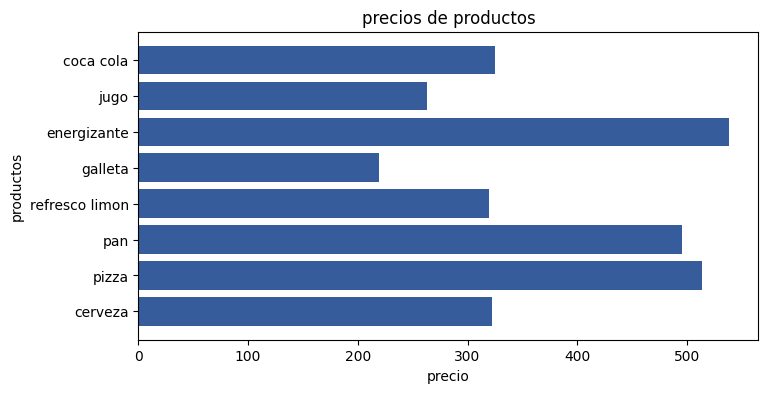

In [ ]:
import matplotlib.pyplot as plt
import codes

categoria, valor = zip(*[(key, value) for key, value in codes.dic_products_percent.items()])

plt.figure(figsize=(8, 4))
plt.barh(categoria, valor, color="#365C9C")  
plt.xlabel("precio")
plt.ylabel("productos")
plt.title("precios de productos")
plt.show()